# Can Water Break Math? Navier-Stokes Explained for Everyone

Have you ever pulled the plug in a bathtub and watched a tiny whirlpool form?

Water looks so simple: you drink it, splash in it, and swim in it every day. But beneath the surface, moving water is playing one of the wildest games of tag in the universe.

Over 175 years ago, two scientists named Claude-Louis Navier and George Gabriel Stokes wrote down a set of math rules called the **Navier-Stokes equations**. These rules tell us how any liquid or gas moves, from the air under an airplane wing to blood pumping through your heart and storms swirling on Jupiter.

Yet mathematicians have been stuck on a giant mystery:

> **Could a swirling fluid ever spin so fast and squeeze so tight that its speed reaches infinity, breaking the math completely?**

This question is so famous that the Clay Mathematics Institute offered a **$1,000,000 prize** to anyone who could solve it.

On September 8, 2026, researchers at OpenAI announced that an automated AI system constructed a formal proof answering part of this million-dollar mystery.

In this notebook, we will take apart the famous equation step by step, play with visual simulations, look at 3D swirling vortices, and see what the AI actually discovered.

## 1. The Famous Equation, Broken Down Piece by Piece

Here is the famous equation in all its glory. Do not let the Greek letters scare you:

$$\frac{\partial u}{\partial t} + (u \cdot \nabla)u = -\nabla p + \nu \nabla^2 u + f$$

Think of it as a balance scale. On the left is **what the fluid wants to do**. On the right is **what is pushing and pulling it**.

Let's translate every single piece into everyday language:

| Symbol | What It Is Called | Real-Life Analogy |
| :--- | :--- | :--- |
| **$u$** | **Velocity** | The speedometer and compass of the fluid. At every single droplet, it tells you how fast the water is moving and in what direction. |
| **$\frac{\partial u}{\partial t}$** | **Acceleration** | The gas pedal. It tracks how fast the water droplet speeds up or slows down right now. |
| **$(u \cdot \nabla)u$** | **Self-Push (Advection)** | Water surfing on itself! Moving water carries its own momentum forward. Fast water bumps into slow water, dragging swirls along with it. |
| **$-\nabla p$** | **Pressure Squeeze** | Squeezing a water balloon or a tube of toothpaste. When pressure builds up in one spot, water shoots out into areas with lower pressure. |
| **$\nu \nabla^2 u$** | **Viscosity (The Honey Effect)** | Molecular friction. Honey has high viscosity; water has low. It acts like a warm iron smoothing out wrinkles on a shirt, calming down sharp spikes. |
| **$f$** | **External Stirring (Forcing)** | An outside push. Think of a spoon stirring hot chocolate, gravity pulling water down a waterfall, or wind blowing across a lake. |

In plain English:

**How water accelerates = Water pushing itself + Pressure squeeze + Friction smoothing it out + Outside stirring**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Clean visual style for plots
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10

# Create a 2D grid of 50 x 50 little water cells
grid_size = 50
x = np.linspace(0, 1, grid_size)
y = np.linspace(0, 1, grid_size)
X, Y = np.meshgrid(x, y)

print(f"Ready! Created a grid of {grid_size} x {grid_size} = {grid_size * grid_size:,} fluid trackers.")

Ready! Created a grid of 50 x 50 = 2,500 fluid trackers.


## 2. Visualizing a Swirling Whirlpool in 2D

Let's drop a swirling disturbance into the center of our grid, just like stirring water in a cup.

In the plot below:
- The **arrows** show which way the water is flowing.
- The **colors** show how fast the water is traveling (yellow and bright orange mean super fast; dark purple means calm and slow).

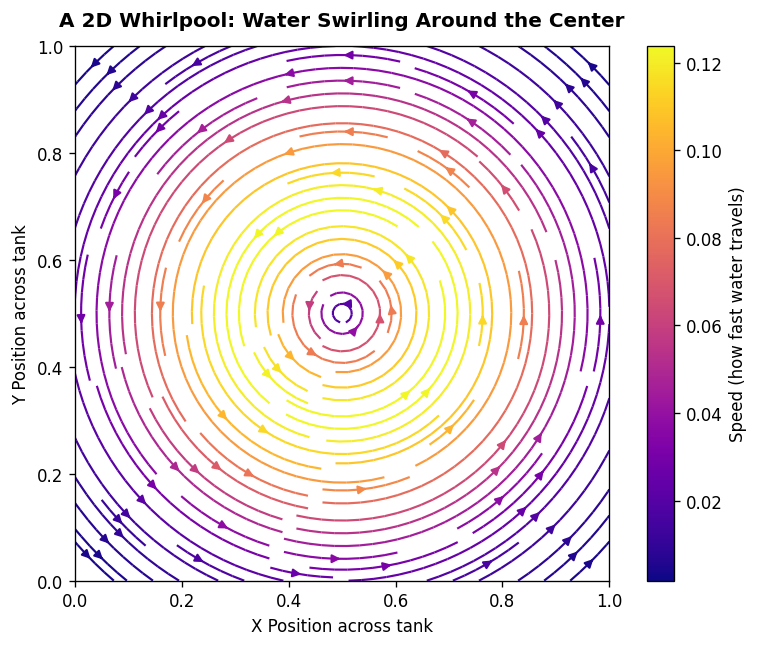

In [2]:
# Center of our mini whirlpool
center_x, center_y = 0.5, 0.5
distance_x = X - center_x
distance_y = Y - center_y
radius_squared = distance_x**2 + distance_y**2

# Swirl speed profile: fast near the center, dying off far away
swirl_strength = 1.0
velocity_u = -swirl_strength * distance_y * np.exp(-12 * radius_squared)
velocity_v =  swirl_strength * distance_x * np.exp(-12 * radius_squared)
speed = np.sqrt(velocity_u**2 + velocity_v**2)

fig, ax = plt.subplots(figsize=(7, 5.5))
stream = ax.streamplot(X, Y, velocity_u, velocity_v, color=speed, cmap="plasma", density=1.4, linewidth=1.3)
cbar = fig.colorbar(stream.lines, ax=ax)
cbar.set_label("Speed (how fast water travels)", rotation=90)

ax.set_title("A 2D Whirlpool: Water Swirling Around the Center", fontweight="bold", pad=12)
ax.set_xlabel("X Position across tank")
ax.set_ylabel("Y Position across tank")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 3. Viscosity: Nature's Smoothing Iron

Look back at the formula for that term with the Greek letter nu ($\nu$):

$$\nu \nabla^2 u$$

This term represents **viscosity**.

Imagine you are in a swimming pool and you kick the water, creating a sharp, sudden wave of speed. What happens a few seconds later? 

The wave does not stay sharp forever. It spreads out and flattens until the pool is calm again. Water molecules rub against each other, turning kinetic energy into tiny amounts of heat.

Viscosity acts like **nature's smoothing iron**:
- If one spot is moving much faster than its neighbors, viscosity slows it down.
- If one spot is lagging behind, neighboring fluid drags it along.

Let's test this in a 1D simulation below. We start with a sudden sharp spike of speed and let viscosity do its work.

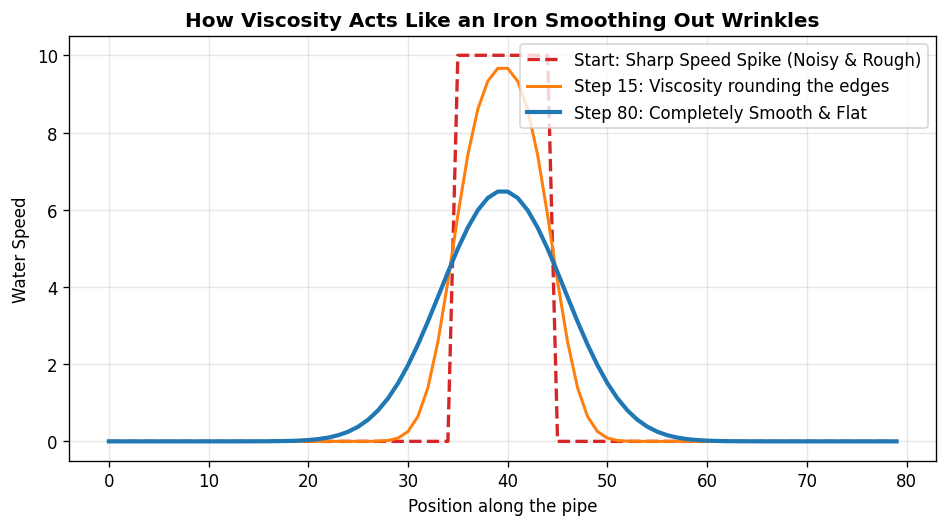

In [3]:
# A 1D line of 80 fluid points with a sharp speed spike in the middle
num_points = 80
speed_profile = np.zeros(num_points)
speed_profile[35:45] = 10.0  # Sharp burst of speed

def apply_viscosity(profile, viscosity_rate=0.18):
    """Simulate molecular friction smoothing out differences between neighbors."""
    smoothed = profile.copy()
    for i in range(1, len(profile) - 1):
        # Second derivative / discrete Laplacian: compare spot to its left and right neighbors
        curvature = profile[i - 1] - 2 * profile[i] + profile[i + 1]
        smoothed[i] += viscosity_rate * curvature
    return smoothed

# Track how the spike changes over 80 steps of smoothing
steps = [speed_profile.copy()]
current = speed_profile.copy()
for _ in range(80):
    current = apply_viscosity(current, viscosity_rate=0.18)
    steps.append(current.copy())

plt.figure(figsize=(8, 4.5))
plt.plot(steps[0], color="#d62728", linestyle="--", linewidth=2, label="Start: Sharp Speed Spike (Noisy & Rough)")
plt.plot(steps[15], color="#ff7f0e", linewidth=1.8, label="Step 15: Viscosity rounding the edges")
plt.plot(steps[-1], color="#1f77b4", linewidth=2.5, label="Step 80: Completely Smooth & Flat")

plt.xlabel("Position along the pipe")
plt.ylabel("Water Speed")
plt.title("How Viscosity Acts Like an Iron Smoothing Out Wrinkles", fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. The 3D Secret: The Figure Skater Effect (Vortex Stretching)

In 2D (like water trapped in a flat puddle between two sheets of glass), whirlpools are well-behaved. Mathematicians proved decades ago that 2D fluids will always stay smooth. They never blow up.

Why? Because in 2D, swirls can only spin flat.

**In 3D, everything changes.**

In 3D space, whirlpools can stretch up and down like elastic rubber bands. This is called **vortex stretching**.

Look at the 3D fluid diagram below:

<div align="center">
  <img src="ns.jpeg" alt="3D Vortex Stretching and Inward Spiral" width="480" style="border-radius: 10px; box-shadow: 0 4px 12px rgba(0,0,0,0.15); margin: 15px 0;"/>
  <p><em>Figure 1: 3D Vortex Stretching. Notice the <strong>axial stretching</strong> pulling along the vertical core and the <strong>inward spiral</strong> squeezing the swirl tighter.</em></p>
</div>

### The Figure Skater Analogy

Have you ever watched an Olympic figure skater spin on ice?
1. The skater starts spinning with their arms outstretched at a modest speed.
2. Then, the skater pulls their arms in tight against their chest.
3. Suddenly, they spin like a blur!

This happens because of a law in physics called **conservation of angular momentum**. When spinning mass is pulled closer to the center, it must spin faster.

In 3D water:
1. When fluid pulls along the vertical line (**axial stretching**), the tube gets thinner.
2. Because it gets thinner, the water gets pulled closer to the center (**inward spiral**).
3. Just like the figure skater pulling in their arms, the swirl spins faster and faster!
4. And here is the scary part: spinning faster causes even stronger suction, which stretches the tube even more!

This creates a **runaway feedback loop**:

```text
Stretching pulls fluid taller
          ↓
Fluid squeezes tighter into the center
          ↓
Water spins even faster (Figure Skater Effect)
          ↓
Stronger spin creates even more stretching!
```

## 5. Visualizing the Runaway Swirl (Concentration)

To see what happens during this runaway loop, let's look at a swirl as it gets squeezed into a tighter, narrower space.

In the four panels below, the vortex gets progressively narrower from left to right. Notice how the colors flare up into bright yellow as the energy concentrates into a tiny pinpoint!

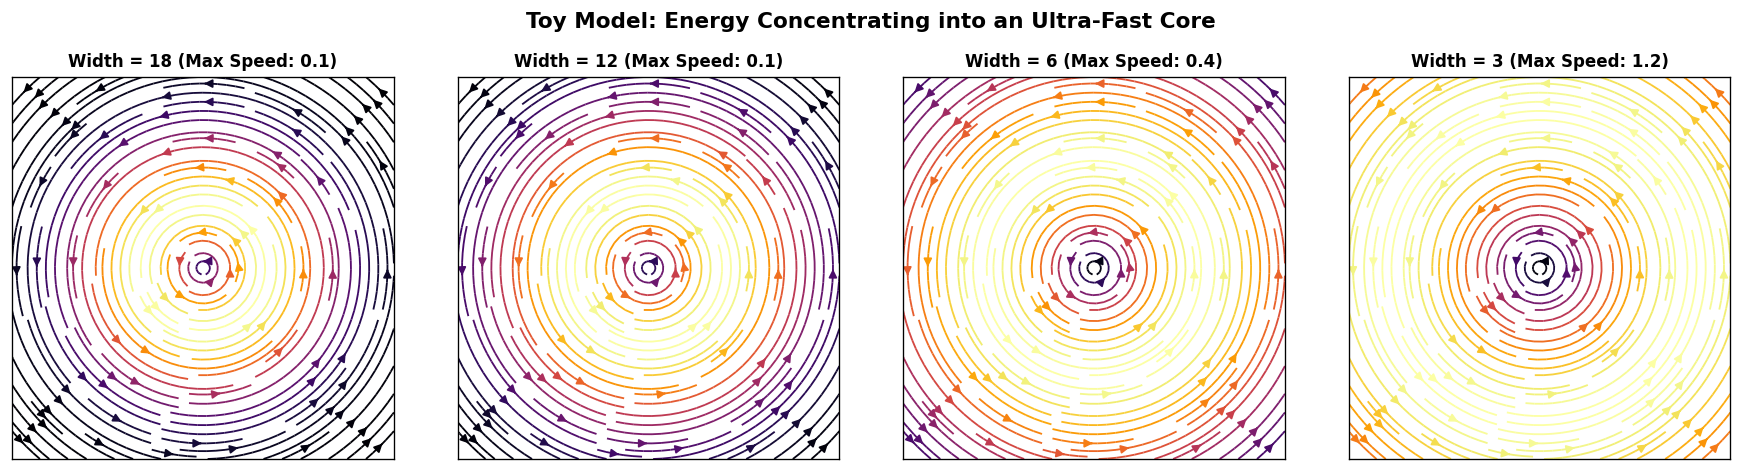

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
widths = [18, 12, 6, 3]

for ax, w in zip(axes, widths):
    dx = X - 0.5
    dy = Y - 0.5
    r2 = dx**2 + dy**2
    
    # As the swirl gets narrower, local speed shoots up
    concentrated_strength = 0.8 * (18.0 / w)
    u_c = -concentrated_strength * dy * np.exp(-w * r2)
    v_c =  concentrated_strength * dx * np.exp(-w * r2)
    speed_c = np.sqrt(u_c**2 + v_c**2)
    
    ax.streamplot(X, Y, u_c, v_c, color=speed_c, cmap="inferno", density=1.4, linewidth=1.1)
    ax.set_title(f"Width = {w} (Max Speed: {speed_c.max():.1f})", fontsize=10, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")

fig.suptitle("Toy Model: Energy Concentrating into an Ultra-Fast Core", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 6. The $1,000,000 Millennium Prize Problem

Now you understand the ultimate tug-of-war in fluid physics:

- **Team Viscosity (Friction):** Trying to smooth everything out, spread the energy, and keep the water calm.
- **Team Vortex Stretching (The Figure Skater):** Trying to stretch the tube, pull everything inward, and spin faster.

In the year 2000, the Clay Mathematics Institute named the **Navier-Stokes Existence and Smoothness Problem** one of the seven greatest unsolved math problems in human history. They offered **$1,000,000** for the answer.

The core question asks:

> **If you start with completely smooth, normal water, can the vortex stretching ever beat viscosity so thoroughly that the water speed shoots all the way to infinity in a finite amount of time?**

If speed hits infinity at some time $T$, mathematicians call this a **finite-time singularity** or **finite-time blow-up**:

$$\lim_{t \to T^-} \|u(t)\| = \infty$$

### Why Computer Simulations Cannot Settle This

You might ask: *"Why don't we just run a computer simulation of water and check?"*

Computers round numbers. A computer breaks water into little cubes (like pixels on a screen). If speed reaches 1,000,000, a computer cannot tell if it stopped at 1,000,000 or if it was heading to true infinity. 

A simulation only tests the exact conditions you clicked play on. A **mathematical proof** has to guarantee what happens in every single case, down to infinite precision.

## 7. What Did OpenAI Actually Solve Yesterday?

On **September 8, 2026**, OpenAI announced a major result: an AI system produced an analytical proof showing that **finite-time blow-up is possible**!

Here is the exact story in simple terms:

### What the AI Did
1. OpenAI set up a swarm of around 10,000 automated AI agents running for 88 hours.
2. The AI tackled **Statements C and D** of the official Millennium Prize Problem.
3. These statements ask: If you are allowed to stir the water with a smooth, continuous push (the outside stirring term $f$ in our formula), can you cause a blow-up?
4. The AI designed a special initial shape and stirring motion where the 3D vortex stretching beats viscosity!
5. In this solution, the water spirals inward, stretches along its axis (just like in **Figure 1**), and its speed shoots straight toward infinity in finite time.
6. The AI then spent 17 hours coding the entire proof into **Lean**, a specialized programming language where computers check every line of math logic without missing a single detail.

### What Does This Mean?
- It means the Navier-Stokes equations **can indeed break down**. The math equations have a point where the water tries to move infinitely fast, causing the equations to glitch!
- In real life, water is made of atoms, so real water would break into steam or quantum particles before hitting infinity. But for the pure math equations, it shows that viscosity is not always strong enough to prevent infinite concentration.

### What Happens Now?
OpenAI has stated they will not claim the $1,000,000 prize. The formal proof and Lean code are now open to the entire global mathematical community for independent verification. Mathematicians are checking every lemma to confirm that the proof holds up.

## 8. Watch It Happen: An Animated Simulation of the Runaway Blow-Up

Here is the entire story brought to life in motion!

In the animation below:
- **Left Panel (The Swirl):** Watch the 2D top-down view of the vortex. As time moves forward, the swirl gets sucked inward and compressed tighter and tighter into a razor-thin core, exactly like the inward spiral we saw earlier. Notice how the colors flare up from dark purple to blazing yellow as the speed concentrates!
- **Right Panel (The Blow-Up Meter):** This tracks the peak water speed over time. At first, the speed climbs gently. But as vortex stretching outruns viscosity, the curve bends sharply upward and rockets straight toward infinity.

Click run on the cell below to watch the runaway feedback loop in action!

In [ ]:
import matplotlib.animation as animation
from IPython.display import Image, display

# Create a clean figure with two side-by-side panels
fig, (ax_flow, ax_speed) = plt.subplots(1, 2, figsize=(12, 5))

# Coordinate grid for the water tank
N_anim = 40
x_a = np.linspace(-1, 1, N_anim)
y_a = np.linspace(-1, 1, N_anim)
Xa, Ya = np.meshgrid(x_a, y_a)
Ra2 = Xa**2 + Ya**2

n_frames = 30
time_steps = np.linspace(0, 0.92, n_frames)
peak_speeds = 1.0 / (1.0 - time_steps)**1.2

def update_frame(frame):
    ax_flow.clear()
    ax_speed.clear()
    
    t = time_steps[frame]
    
    # 1. Update fluid vortex (inward suction and tighter spin)
    tightness = 2.0 + 20.0 * (t ** 1.5)
    core_power = 1.0 / (1.0 - t)**0.8
    
    u_anim = -core_power * Ya * np.exp(-tightness * Ra2) - 0.25 * core_power * Xa * np.exp(-tightness * Ra2)
    v_anim =  core_power * Xa * np.exp(-tightness * Ra2) - 0.25 * core_power * Ya * np.exp(-tightness * Ra2)
    current_speed = np.sqrt(u_anim**2 + v_anim**2)
    
    ax_flow.streamplot(Xa, Ya, u_anim, v_anim, color=current_speed, cmap='inferno', density=1.3, linewidth=1.2)
    ax_flow.set_title(f"Fluid Motion at Time t = {t:.2f}s\n(Swirl Squeezing Inward)", fontsize=11, fontweight='bold')
    ax_flow.set_xlim(-1, 1)
    ax_flow.set_ylim(-1, 1)
    ax_flow.set_aspect('equal')
    ax_flow.set_xticks([])
    ax_flow.set_yticks([])
    
    # 2. Update the Blow-Up Meter graph
    ax_speed.plot(time_steps[:frame+1], peak_speeds[:frame+1], color='#d62728', lw=2.5, label='Peak Speed')
    ax_speed.scatter(time_steps[frame], peak_speeds[frame], color='red', s=70, zorder=5)
    ax_speed.set_xlim(0, 1.0)
    ax_speed.set_ylim(0, max(peak_speeds) * 1.08)
    ax_speed.set_xlabel('Time (seconds)')
    ax_speed.set_ylabel('Peak Water Speed')
    ax_speed.set_title('The Blow-Up Meter: Speed Spikes to Infinity!', fontsize=11, fontweight='bold')
    ax_speed.grid(True, alpha=0.3)
    
    if frame >= n_frames - 4:
        ax_speed.annotate('SINGULARITY!\n(Finite-Time Blow-Up)', 
                          xy=(time_steps[frame], peak_speeds[frame]),
                          xytext=(time_steps[frame] - 0.38, peak_speeds[frame] * 0.78),
                          arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7),
                          fontweight='bold', color='crimson')

plt.tight_layout()

# Build and save the animation
anim = animation.FuncAnimation(fig, update_frame, frames=n_frames, repeat=True)
anim.save('vortex_blowup.gif', writer='pillow', fps=10)
plt.close(fig)

# Display the looped animation directly in the notebook
display(Image('vortex_blowup.gif'))